# Milestone 2: Threat Index Development

# Project Contributions

This notebook was completed collaboratively by all group members. Contributions include:

Alec: Data download and processing, index design, threat index visualization, addition of events, and Python scripting.

Ashton: Index design, algorithum implementation, threat index visualization, automated plot generation, markdown documentation, and overall notebook organization.

Both members contributed to the development and refinement of the threat index, as well as reviewing and finalizing the notebook for submission.

# 1. Threat Index Design

## Hazard and Focus
This threat index is designed to assess **severe convective thunderstorm potential**, focusing on environmental conditions that support thunderstormstorm initiation.

## Target Audience
The index is intended for:
- Emergency managers  
- Event planners  
- The general public
- transportation officals  

This index provides a simple, interpretable measure of thunderstorm probability that can be used for decision-making and situational awareness.

## Index Scale
The index ranges from **0 to 100**:

- 0 = Low chance of thunderstorm developemnt
- 100 = High chance of thunderstorm development

## Selected Variables
The following meteorological variables were chosen because they represent the key ingredients required for severe thunderstorm development:

- 2-meter Temperature 
- 2-meter Dewpoint
- Low-level winds (convergence)
- CAPE (Convective Available Potential Energy)
- CIN (Convective Inhibition)
- Total Cloud Cover 

## Physical Reasoning
The index incorporates the key ingredients for thunderstorm development, including instability (represented by temperature and CAPE), moisture (represented by dewpoint), lift (represented by low-level winds), and inhibition (represented by CIN); favorable environments occur when these factors are balanced in a way that promotes rising air and storm development.

## Variable Ranges

### Favorable Conditions for Thunderstorm Developement:
- Temperature: 60–90°F  
- Dewpoint: 55–75°F  
- Convergence: Positive values (indicating converging winds and rising motion)  
- CAPE: 1000–2500 J/kg  
- CIN: < 50 J/kg  
- Cloud Cover: 40–100%  

### Unfavorable Conditions for Thunderstorm Development:
- Temperature: <60°F or >90°F  
- Dewpoint: <55°F  
- Convergence: Negative values (divergence, indicating sinking air)  
- CAPE: near 0 J/kg  
- CIN: >50–200 J/kg  
- Cloud Cover: <40%  

## Variable Weights
- Temperature: 15%  
- Dewpoint: 25%  
- Low-level Convergence (Lift): 5%  
- CAPE: 30%  
- CIN: 20%  
- Cloud Cover: 5%  

## Index Formula and Logic
Each variable is first transformed into a **normalized contribution between 0 and 100** using physically meaningful functions (such as Gaussian, logistic, or exponential relationships). These functions ensure that each variable contributes to the index in a realistic and continuous way based on how favorable conditions are for severe thunderstorms.

The final threat index is calculated as a **weighted sum** of all variable contributions:

**Index = (0.15 × Temperature) + (0.25 × Dewpoint) + (0.05 × Convergence) + (0.30 × CAPE) + (0.20 × CIN) + (0.05 × Cloud Cover)**

### How the Formula Works

- Each variable contributes a value between 0 and 100 based on how favorable conditions are  
- These values are multiplied by their respective weights to reflect their relative importance  
- The weighted contributions are summed to produce a final index value between 0 and 100  

This ensures the index is **interpretable**, where higher values indicate a greater likelihood of severe thunderstorm development.

### Why the Formula Makes Sense

The structure of the formula reflects the physical processes required for severe thunderstorms:

- **CAPE** is heavily weighted because it represents atmospheric instability and the potential for strong updrafts  
- **CIN** is also heavily weighted because it controls whether storms can form at all  
- **Convergence** is important for initiating upward motion and triggering convection  
- **Dewpoint** contributes moisture, which is necessary for storm development  
- **Temperature** supports instability but plays a secondary role  
- **Cloud Cover** provides additional context for storm organization  

### Logical Behavior of the Index

The index behaves logically under different atmospheric conditions:

- High CAPE and low CIN → high index values (favorable for severe storms)  
- Low moisture or strong inhibition → low index values (unfavorable conditions)  
- Moderate conditions across variables → moderate index values  

This ensures the index responds realistically to changes in the atmospheric environment.

## Usefulness of the Index

This index simplifies complex atmospheric data into a single value that can be easily interpreted by users. It allows decision-makers to quickly assess thunderstorm development risk without needing to interpret multiple meteorological variables.

This makes it especially useful for:
- Real-time situational awareness  
- Planning outdoor events  
- Emergency response preparation  

# 2. Algorithm Implementation

A function to calculate a thunderstorm probability index was implemented in the code cells below for both the incident day and the null day to support evaluation of the index. This function accepts relevant meteorological variables as input and returns an array of computed index values representing the likelihood of thunderstorm development.

In [245]:
# Import Statements
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import metpy.calc as mpcalc
from metpy.units import units
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from metpy.calc import lat_lon_grid_deltas
import os


In [246]:
# Load Data for Incident Day
ds1 = xr.open_dataset('MergedIncident')
ds1 = ds1.sortby('valid_time')
ds1

sh: 1: getfattr: not found


<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-10 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    u10                (valid_time, y, x) float32 373MB ...
    v10                (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-01T15:45 GRIB to CDM+CF via cfgrib-0.9.1...

In [247]:
# Choose one time index (you can change this later)
fcst1 = ds1.isel(valid_time=48)

# Extract initialization and valid times
init_time = pd.to_datetime(ds1.time.values)
valid_time = pd.to_datetime(fcst1.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

# Print out initial and valid times
print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Oct 10 2021
Valid Time: 00Z Oct 12 2021


In [248]:
# Convert temperatures to Fahrenheit
temp_f = (fcst1['t2m'] - 273.15) * 9/5 + 32
dewpt_f = (fcst1['d2m'] - 273.15) * 9/5 + 32

cape = fcst1['cape']
cin = fcst1['cin']
cloud = fcst1['tcc'] * 100

# Compute dx and dy from lat/lon
dx, dy = lat_lon_grid_deltas(fcst1['longitude'].values, fcst1['latitude'].values)

# Compute convergence (negative divergence)
convergence = -mpcalc.divergence(fcst1['u10'], fcst1['v10'], dx=dx, dy=dy)

# Define function for Threat Index
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):

    # Temperature (best 60–90°F)
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)

    # Dewpoint (logistic growth)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))

    # CAPE (exponential growth)
    cape_index = 100 * (1 - np.exp(-cape / 1000))

    # CIN (inverse exponential decay)
    cin_index = 100 * np.exp(-np.abs(cin) / 100)

    # Cloud cover (logistic)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))

    # Convergence (scaled)
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

    # Weighted Index Calculation
    index1 = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)

    return index1

# Print index maximum and minimum values
index1 = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)
index1

/tmp/ipykernel_355994/3549201172.py:13: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst1['u10'], fcst1['v10'], dx=dx, dy=dy)


<xarray.DataArray (y: 1059, x: 1799)> Size: 15MB
array([[58.45206255, 58.56454653, 58.56454653, ..., 89.16470938,
        89.26656482, 89.45649562],
       [58.53204149, 58.20402712, 57.8080005 , ..., 89.1101609 ,
        88.84894965, 89.40207987],
       [58.60910219, 57.92382616, 57.94037269, ..., 89.16452952,
        88.80926417, 89.19770325],
       ...,
       [29.72504085, 29.5103726 , 29.27201107, ..., 30.42055035,
        30.45560741, 30.62032231],
       [29.72609752, 29.40271598, 29.45755495, ..., 30.42055035,
        30.45560741, 30.49134016],
       [29.72869295, 29.72609752, 29.72504085, ..., 30.31115723,
        30.45560741, 30.49134016]], shape=(1059, 1799))
Coordinates:
    time               datetime64[ns] 8B 2021-10-10
    step               timedelta64[ns] 8B 2 days
    heightAboveGround  float64 8B 10.0
    latitude           (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude          (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    valid_time         datetime64[ns] 8B 2021-10-12
    surface            float64 8B 0.0
    atmosphere         float64 8B 0.0
Dimensions without coordinates: y, x
Attributes: (12/26)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1905141
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            lambert
    GRIB_uvRelativeToGrid:                    1
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   21.138123
    GRIB_latitudeOfSouthernPoleInDegrees:     0.0
    GRIB_longitudeOfFirstGridPointInDegrees:  237.280472
    GRIB_longitudeOfSouthernPoleInDegrees:    0.0
    GRIB_missingValue:                        3.4028234663852886e+38
    standard_name:                            unknown

In [249]:
# Load Data for Null Day
ds2 = xr.open_dataset('MergedNull')
ds2 = ds2.sortby('valid_time')
ds2

sh: 1: getfattr: not found


<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-13 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    u10                (valid_time, y, x) float32 373MB ...
    v10                (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-08T19:04 GRIB to CDM+CF via cfgrib-0.9.1...

In [250]:
# Choose one time index (you can change this later)
fcst2 = ds2.isel(valid_time=48)

# Extract initialization and valid times
init_time = pd.to_datetime(ds2.time.values)
valid_time = pd.to_datetime(fcst2.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

# Print out initial and valid times
print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Oct 13 2021
Valid Time: 00Z Oct 15 2021


In [251]:
# Convert temperatures to Fahrenheit
temp_f = (fcst2['t2m'] - 273.15) * 9/5 + 32
dewpt_f = (fcst2['d2m'] - 273.15) * 9/5 + 32

cape = fcst2['cape']
cin = fcst2['cin']
cloud = fcst2['tcc'] * 100

# Compute dx and dy from lat/lon
dx, dy = lat_lon_grid_deltas(fcst2['longitude'].values, fcst2['latitude'].values)

# Compute convergence (negative divergence)
convergence = -mpcalc.divergence(fcst2['u10'], fcst2['v10'], dx=dx, dy=dy)

# Define function for Threat Index
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):

    # Temperature (best 60–90°F)
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)

    # Dewpoint (logistic growth)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))

    # CAPE (exponential growth)
    cape_index = 100 * (1 - np.exp(-cape / 1000))

    # CIN (inverse exponential decay)
    cin_index = 100 * np.exp(-np.abs(cin) / 100)

    # Cloud cover (logistic)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))

    # Convergence (scaled)
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

     # Weighted Index Calculation
    index2 = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)

    return index2

# Printed out index maximum and minimum values
index2 = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)
index2

/tmp/ipykernel_355994/3650666125.py:13: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst2['u10'], fcst2['v10'], dx=dx, dy=dy)


<xarray.DataArray (y: 1059, x: 1799)> Size: 15MB
array([[59.84623861, 59.62671041, 59.2039094 , ..., 87.80268419,
        87.61668396, 87.77984721],
       [59.71445799, 58.38900161, 57.93630147, ..., 87.20577471,
        87.15138626, 87.67107613],
       [59.68978453, 58.05753255, 57.76927635, ..., 87.15138626,
        87.15138626, 87.61668397],
       ...,
       [33.65241909, 34.02212046, 33.91649354, ..., 27.75129199,
        27.96042606, 28.36270601],
       [33.91648981, 33.91649019, 33.81086429, ..., 27.80198348,
        27.95938812, 28.60324869],
       [33.70524601, 33.65241909, 33.65241909, ..., 27.88739216,
        27.90664208, 28.23352998]], shape=(1059, 1799))
Coordinates:
    time               datetime64[ns] 8B 2021-10-13
    step               timedelta64[ns] 8B 2 days
    heightAboveGround  float64 8B 10.0
    latitude           (y, x) float64 15MB 21.14 21.15 21.15 ... 47.85 47.84
    longitude          (y, x) float64 15MB 237.3 237.3 237.3 ... 299.0 299.1
    valid_time         datetime64[ns] 8B 2021-10-15
    surface            float64 8B 0.0
    atmosphere         float64 8B 0.0
Dimensions without coordinates: y, x
Attributes: (12/26)
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      1905141
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    GRIB_gridType:                            lambert
    GRIB_uvRelativeToGrid:                    1
    ...                                       ...
    GRIB_latitudeOfFirstGridPointInDegrees:   21.138123
    GRIB_latitudeOfSouthernPoleInDegrees:     0.0
    GRIB_longitudeOfFirstGridPointInDegrees:  237.280472
    GRIB_longitudeOfSouthernPoleInDegrees:    0.0
    GRIB_missingValue:                        3.4028234663852886e+38
    standard_name:                            unknown

# 3. Threat Index Visualization

In [231]:
# Choose one time index (you can change this later)
fcst1 = ds1.isel(valid_time=48) 


# Extract initialization and valid times
init_time = pd.to_datetime(ds1.time.values)
valid_time = pd.to_datetime(fcst1.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y') 

# Print out initial and valid times
print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Oct 10 2021
Valid Time: 00Z Oct 12 2021


In [232]:
# Extract 10-meter wind components and compute wind speed magnitude
u10 = fcst1['u10']
v10 = fcst1['v10']
wind_speed = np.sqrt(u10**2 + v10**2)

In [233]:
# CONUS Map Function
def conus_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)

    return fig, ax

In [234]:
# CONUS Map Function
def make_conus_ax(ax):

    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return ax

# Set bounds for index map
bounds = np.linspace(0, 100, 101)

# Use BoundaryNorm to force exact colorbar edges
norm = mcolors.BoundaryNorm(bounds, ncolors=256)

def make_layout():
    fig, axes = plt.subplot_mosaic(
        [
            ["main", "main", "ax1", "ax2"],
            ["main", "main", "ax3", "ax4"],
            ["ax5",  "ax5",  "ax6", "ax6"],
        ],
        subplot_kw={"projection": ccrs.PlateCarree()},
        figsize=(20, 12),
        layout="constrained"
    )

    ax_main = axes["main"]
    ax1 = axes["ax1"]
    ax2 = axes["ax2"]
    ax3 = axes["ax3"]
    ax4 = axes["ax4"]
    ax5 = axes["ax5"]
    ax6 = axes["ax6"]

    for ax in [ax_main, ax1, ax2, ax3, ax4, ax5, ax6]:
        make_conus_ax(ax)
        
    return (fig, axes["main"],axes["ax1"], axes["ax2"],axes["ax3"], axes["ax4"],axes["ax5"], axes["ax6"])

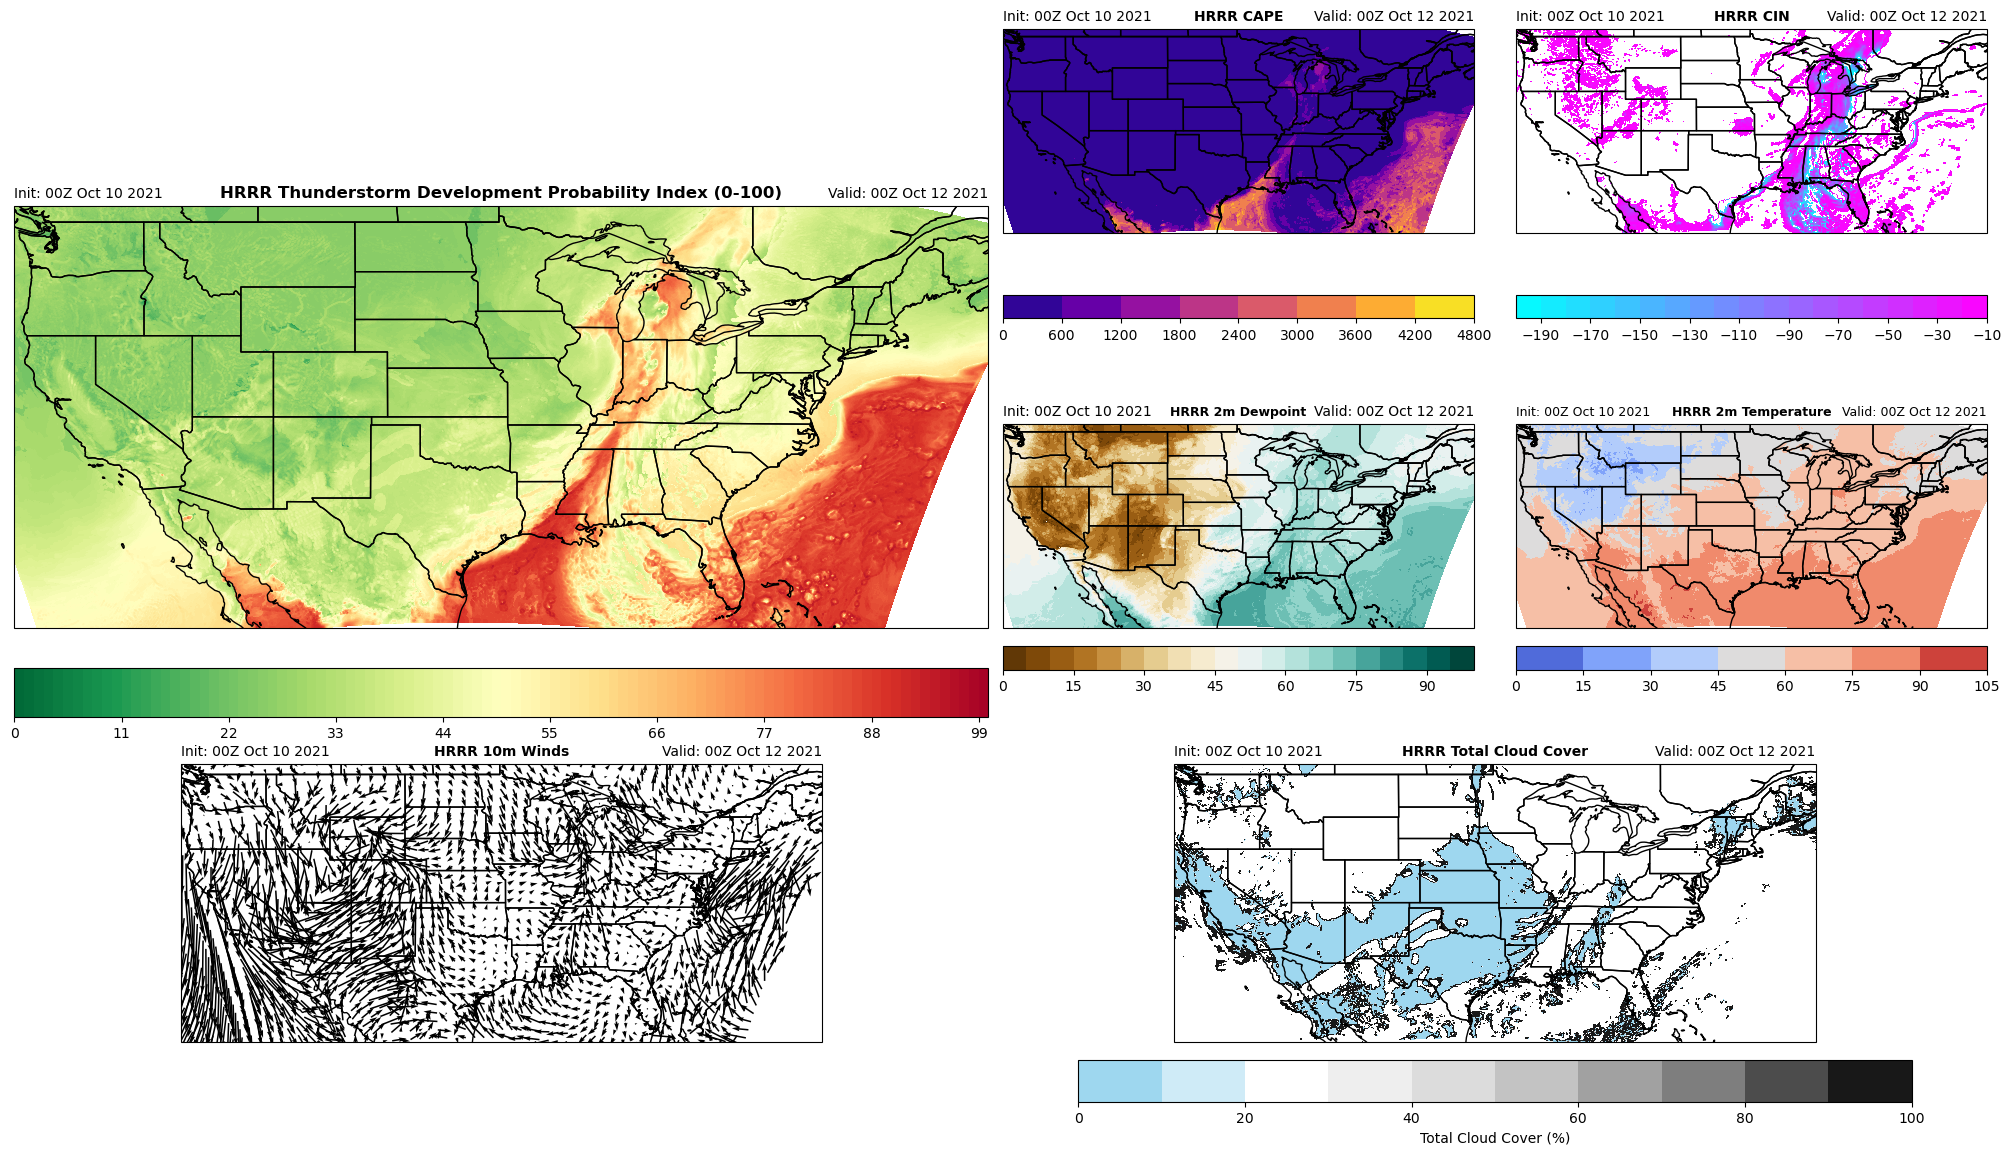

In [235]:
fig, ax_main, ax1, ax2, ax3, ax4, ax5, ax6 = make_layout()

# --- Main Map (Threat Index) ---
cf = ax_main.contourf(ds1.longitude, ds1.latitude, index1, levels=bounds,
                      cmap='RdYlGn_r',
                      transform=ccrs.PlateCarree())
cbar = plt.colorbar(cf, ax=ax_main, orientation='horizontal', pad=0.05)
ax_main.set_title("HRRR Thunderstorm Development Probability Index (0-100)", loc='center', fontweight='bold')
ax_main.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax_main.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 1 (CAPE) ---
cape = fcst1['cape']
cf1 = ax1.contourf(ds1.longitude, ds1.latitude, cape,
                   transform=ccrs.PlateCarree(), cmap='plasma')
plt.colorbar(cf1, ax=ax1, orientation='horizontal', pad=0.01)
ax1.set_title("HRRR CAPE", loc='center', fontweight='bold', fontsize=10)
ax1.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax1.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)


# --- Map 2 (CIN)---

cin = fcst1['cin']
cf2 = ax2.contourf(ds1.longitude, ds1.latitude, cin, levels = np.arange(-200, 0, 10),
                   transform=ccrs.PlateCarree(), cmap='cool')
plt.colorbar(cf2, ax=ax2, orientation='horizontal', pad=0.01)
ax2.set_title("HRRR CIN", loc='center', fontweight='bold', fontsize=10)
ax2.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax2.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 3 (2m Dewpoint)---
dew = (fcst1['d2m'] - 273.15) * 9/5 + 32
cf3 = ax3.contourf(ds1.longitude, ds1.latitude, dew, levels = np.arange(0, 105, 5),
                   transform=ccrs.PlateCarree(), cmap='BrBG')
plt.colorbar(cf3, ax=ax3, orientation='horizontal', pad=0.05)
ax3.set_title("HRRR 2m Dewpoint", loc='center', fontweight='bold', fontsize=9)
ax3.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax3.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 4 (2m Temperature)---
temp = (fcst1['t2m'] - 273.15) * 9/5 + 32
cf4 = ax4.contourf(ds1.longitude, ds1.latitude, temp,
                   transform=ccrs.PlateCarree(), cmap='coolwarm')
plt.colorbar(cf4, ax=ax4, orientation='horizontal', pad=0.05)
ax4.set_title("HRRR 2m Temperature", loc='center', fontweight='bold', fontsize=9)
ax4.set_title(f"Init: {init_str}",   loc='left', fontsize=9)
ax4.set_title(f"Valid: {valid_str}", loc='right', fontsize=9)

# --- Map 5 (10m Wind Vectors) ---
skip = 30
cf5 = ax5.quiver(ds1.longitude[::skip, ::skip],
          ds1.latitude[::skip, ::skip],
          u10[::skip, ::skip],
          v10[::skip, ::skip],
          transform=ccrs.PlateCarree(),
          scale=200)

ax5.set_title("HRRR 10m Winds", loc='center', fontweight='bold', fontsize=10)
ax5.set_title(f"Init: {init_str}", loc='left', fontsize=10)
ax5.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 6 (Cloud Cover) ---

cloud_colors = ['skyblue', 'white', 'lightgray', 'gray', 'black']
cloud_cmap = LinearSegmentedColormap.from_list('clouds', cloud_colors)

cloud = fcst1['tcc'] * 100  # convert to %

cf6 = ax6.contourf(ds1.longitude, ds1.latitude, cloud,
                 levels=np.arange(0, 101, 10),
                 cmap=cloud_cmap,
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf6, ax=ax6, orientation='horizontal', pad=0.05)
cbar.set_label('Total Cloud Cover (%)')
ax6.set_title("HRRR Total Cloud Cover", loc='center', fontweight='bold', fontsize=10)
ax6.set_title(f"Init: {init_str}", loc='left', fontsize=10)
ax6.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

plt.show()


In [236]:
# Choose one time index (you can change this later)
fcst2 = ds2.isel(valid_time=48) 


# Extract initialization and valid times
init_time = pd.to_datetime(ds2.time.values)
valid_time = pd.to_datetime(fcst2.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

# Print out initial and valid times
print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Oct 13 2021
Valid Time: 00Z Oct 15 2021


In [238]:
# Extract 10-meter wind components and compute wind speed magnitude
u10 = fcst1['u10']
v10 = fcst1['v10']
wind_speed = np.sqrt(u10**2 + v10**2)

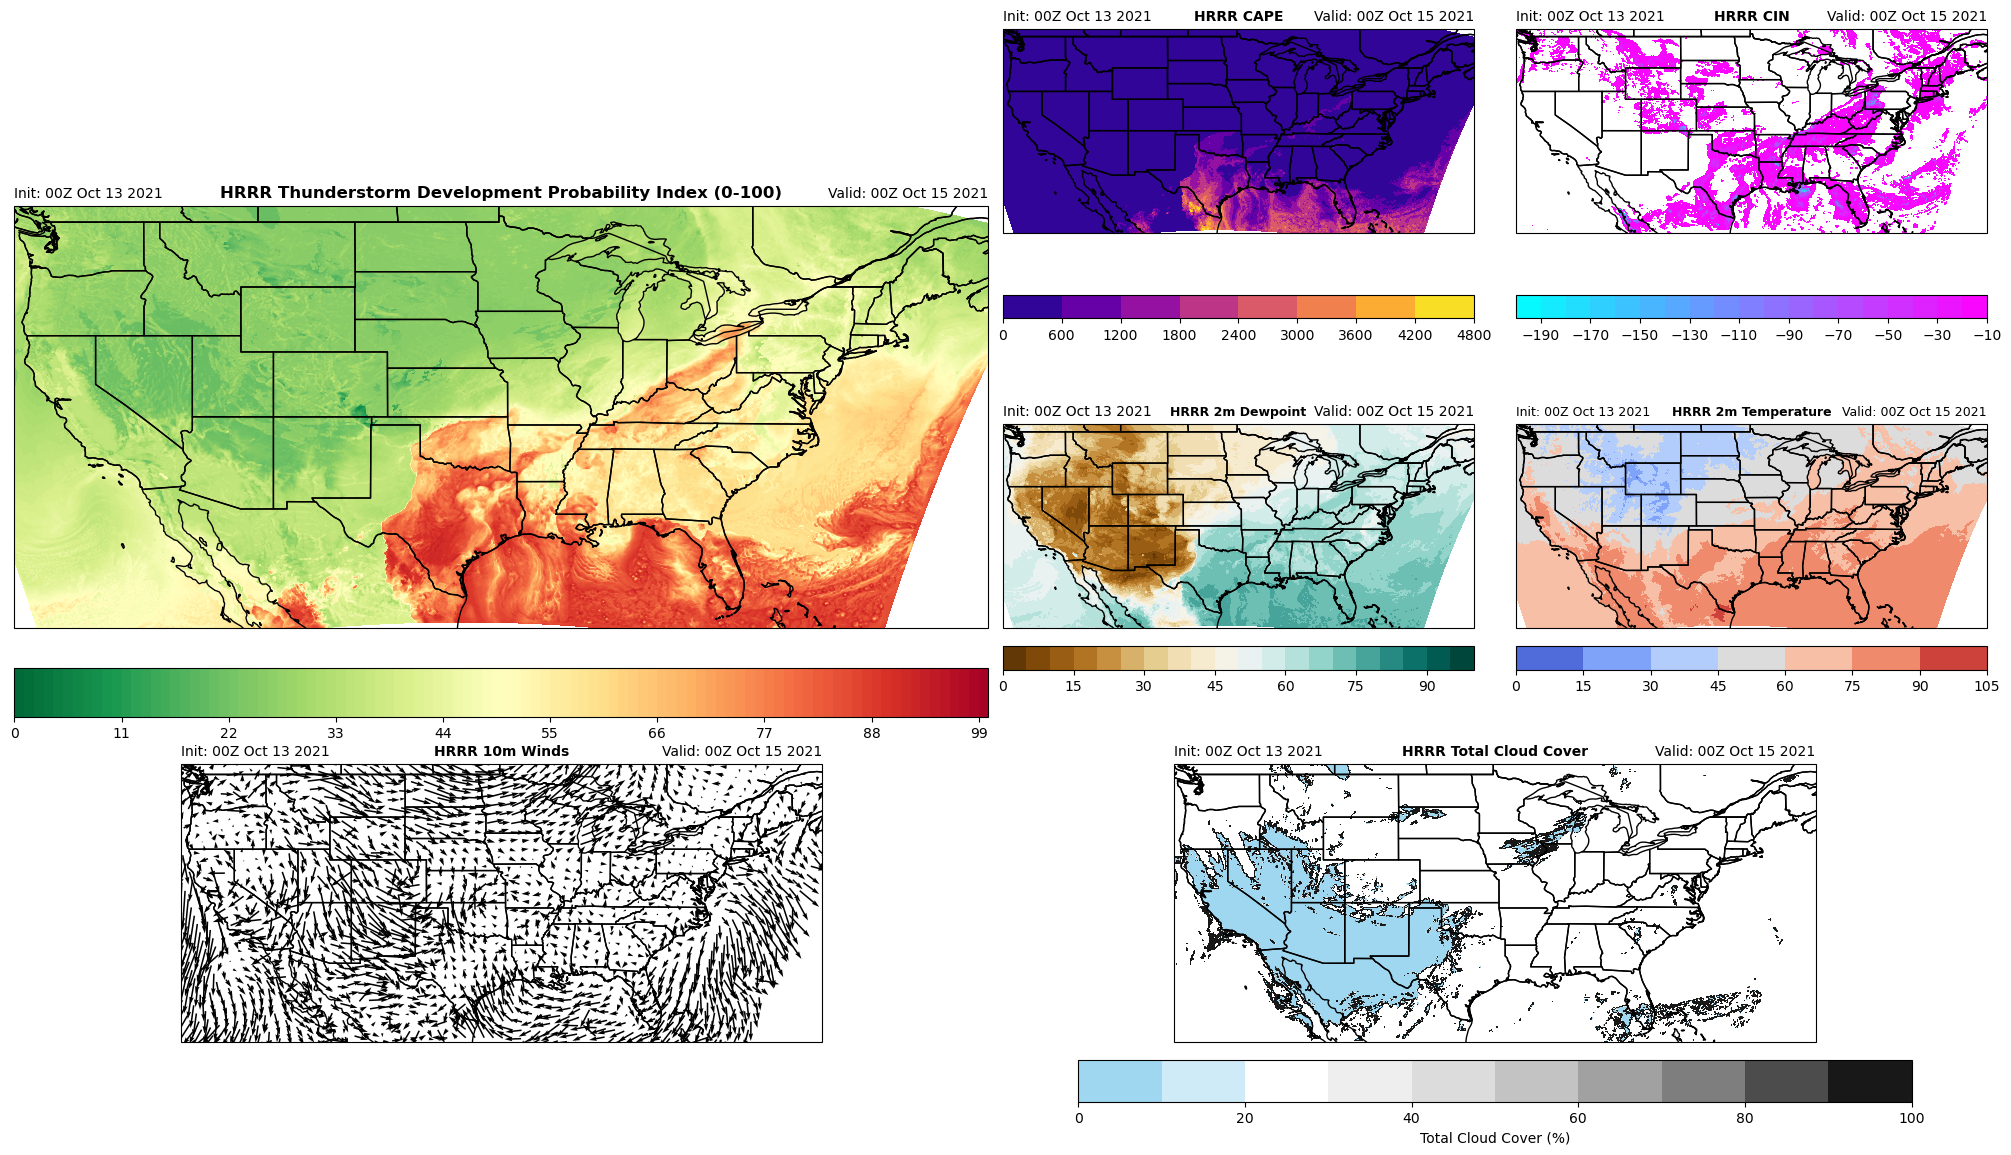

In [239]:
fig, ax_main, ax1, ax2, ax3, ax4, ax5, ax6 = make_layout()

# --- Main Map (Threat Index) ---
cf = ax_main.contourf(ds2.longitude, ds2.latitude, index2, levels=bounds,
                      cmap='RdYlGn_r',
                      transform=ccrs.PlateCarree())
cbar = plt.colorbar(cf, ax=ax_main, orientation='horizontal', pad=0.05)
ax_main.set_title("HRRR Thunderstorm Development Probability Index (0-100)", loc='center', fontweight='bold')
ax_main.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax_main.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 1 (CAPE) ---
cape = fcst2['cape']
cf1 = ax1.contourf(ds2.longitude, ds2.latitude, cape,
                   transform=ccrs.PlateCarree(), cmap='plasma')
plt.colorbar(cf1, ax=ax1, orientation='horizontal', pad=0.01)
ax1.set_title("HRRR CAPE", loc='center', fontweight='bold', fontsize=10)
ax1.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax1.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)


# --- Map 2 (CIN) ---

cin = fcst2['cin']
cf2 = ax2.contourf(ds2.longitude, ds2.latitude, cin, levels = np.arange(-200, 0, 10),
                   transform=ccrs.PlateCarree(), cmap='cool')
plt.colorbar(cf2, ax=ax2, orientation='horizontal', pad=0.01)
ax2.set_title("HRRR CIN", loc='center', fontweight='bold', fontsize=10)
ax2.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax2.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 3 (2m Dewpoint) ---
dew = (fcst2['d2m'] - 273.15) * 9/5 + 32
cf3 = ax3.contourf(ds2.longitude, ds2.latitude, dew, levels = np.arange(0, 105, 5),
                   transform=ccrs.PlateCarree(), cmap='BrBG')
plt.colorbar(cf3, ax=ax3, orientation='horizontal', pad=0.05)
ax3.set_title("HRRR 2m Dewpoint", loc='center', fontweight='bold', fontsize=9)
ax3.set_title(f"Init: {init_str}",   loc='left', fontsize=10)
ax3.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 4 (2m Temperature) ---
temp = (fcst2['t2m'] - 273.15) * 9/5 + 32
cf4 = ax4.contourf(ds2.longitude, ds2.latitude, temp,
                   transform=ccrs.PlateCarree(), cmap='coolwarm')
plt.colorbar(cf4, ax=ax4, orientation='horizontal', pad=0.05)
ax4.set_title("HRRR 2m Temperature", loc='center', fontweight='bold', fontsize=9)
ax4.set_title(f"Init: {init_str}",   loc='left', fontsize=9)
ax4.set_title(f"Valid: {valid_str}", loc='right', fontsize=9)

# --- Map 5 (10m Wind Vectors) ---
skip = 30
cf5 = ax5.quiver(ds2.longitude[::skip, ::skip],
          ds2.latitude[::skip, ::skip],
          u10_2[::skip, ::skip],
          v10_2[::skip, ::skip],
          transform=ccrs.PlateCarree(),
          scale=200)

ax5.set_title("HRRR 10m Winds", loc='center', fontweight='bold', fontsize=10)
ax5.set_title(f"Init: {init_str}", loc='left', fontsize=10)
ax5.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

# --- Map 6 (Cloud Cover) ---

cloud_colors = ['skyblue', 'white', 'lightgray', 'gray', 'black']
cloud_cmap = LinearSegmentedColormap.from_list('clouds', cloud_colors)

cloud = fcst2['tcc'] * 100  # convert to %

cf6 = ax6.contourf(ds2.longitude, ds2.latitude, cloud,
                 levels=np.arange(0, 101, 10),
                 cmap=cloud_cmap,
                 transform=ccrs.PlateCarree())

cbar = plt.colorbar(cf6, ax=ax6, orientation='horizontal', pad=0.05)
cbar.set_label('Total Cloud Cover (%)')
ax6.set_title("HRRR Total Cloud Cover", loc='center', fontweight='bold', fontsize=10)
ax6.set_title(f"Init: {init_str}", loc='left', fontsize=10)
ax6.set_title(f"Valid: {valid_str}", loc='right', fontsize=10)

plt.show()


# 4. Testing on Additional Events

## High-End Event Evaluation
The index formula was tested on the April 1, 2025 in which a severe weather outbreak occured to evaluate the performance in a high-end scenario. It produced consistently high values across regions by severe weather, indicating it effectively captured favorable conditions for strong convection. There were no major missed threats, as areas with observed severe weather aligned well with elevated index values, though some localized overestimation occurred due to convergent winds and cloud cover. Overall, the algorithm performed well, producing reasonable and accurate results with only minor adjustments needed to fine-tune the magnitude.

## Low-End Event Evaluation

The index formula was also tested on January 25, 2025 to assess performance in a low-end, non-severe scenario. The index produced generally low values across the domain, correctly indicating limited to no severe weather potential, with any convection mainly confined over the ocean where conditions were more favorable. There were minimal false alarms, though a few isolated areas showed slightly elevated values despite no observed severe weather, suggesting minor sensitivity to weak forcing or background conditions. Overall, the algorithm successfully identified a non-severe environment with reasonable performance. However, the index formula required several revisions throughout the process to improve accuracy and reduce errors, resulting in noticeable adjustments to the final version.

In [252]:
# Load Data for High-End Event
ds3 = xr.open_dataset('MergedHighEndEvent')
ds3 = ds3.sortby('valid_time')
ds3

sh: 1: getfattr: not found


<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2025-04-01 ... 2025-0...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
    u10                (valid_time, y, x) float32 373MB ...
    v10                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-08T15:53 GRIB to CDM+CF via cfgrib-0.9.1...

In [253]:
# Choose one time index (you can change this later)
fcst3 = ds3.isel(valid_time=48)

# Extract initialization and valid times
init_time = pd.to_datetime(ds3.time.values)
valid_time = pd.to_datetime(fcst3.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

# Print initial and valid times
print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Apr 01 2025
Valid Time: 00Z Apr 03 2025


In [254]:
# Convert temperatures to Fahrenheit
temp_f = (fcst3['t2m'] - 273.15) * 9/5 + 32
dewpt_f = (fcst3['d2m'] - 273.15) * 9/5 + 32

cape = fcst3['cape']
cin = fcst3['cin']
cloud = fcst3['tcc'] * 100

# Compute dx and dy from lat/lon
dx, dy = lat_lon_grid_deltas(fcst3['longitude'].values, fcst3['latitude'].values)

# Compute convergence (negative divergence)
convergence = -mpcalc.divergence(fcst3['u10'], fcst3['v10'], dx=dx, dy=dy)

# Define function for Threat Index
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):

    # Temperature (best 60–90°F)
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)

    # Dewpoint (logistic growth)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))

    # CAPE (exponential growth)
    cape_index = 100 * (1 - np.exp(-cape / 1000))

    # CIN (inverse exponential decay)
    cin_index = 100 * np.exp(-np.abs(cin) / 100)

    # Cloud cover (logistic)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))

    # Convergence (scaled)
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

     # Weighted Index Calculation
    index3 = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)

    return index3

# Printed out index maximum and minimum values
index3 = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)

/tmp/ipykernel_355994/3574160584.py:13: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst3['u10'], fcst3['v10'], dx=dx, dy=dy)


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


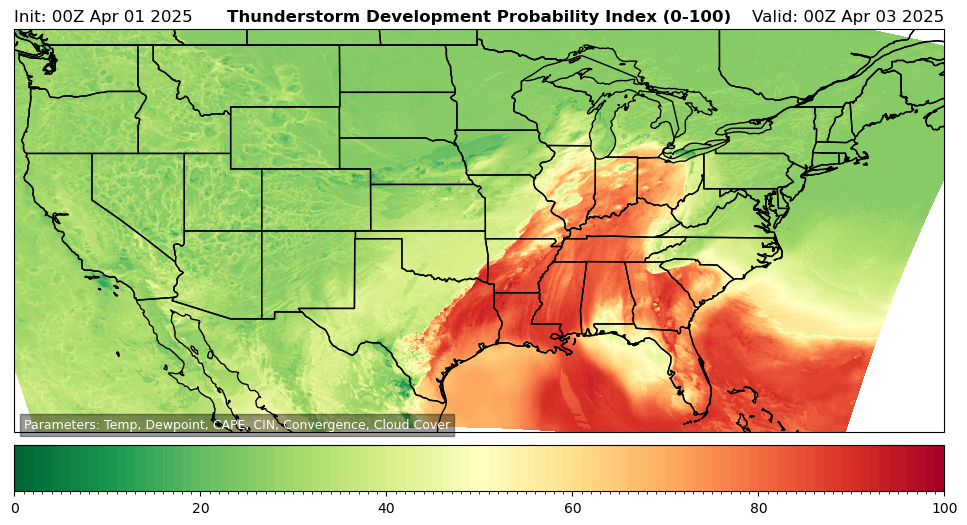

In [255]:
fig, ax = conus_map()

# Define exact boundaries for 0–100
bounds = np.linspace(0, 100, 101)

# Use BoundaryNorm to force exact colorbar edges
norm = mcolors.BoundaryNorm(bounds, ncolors=256)

# Plot with fixed boundaries
c = ax.contourf(
    fcst3['longitude'], 
    fcst3['latitude'], 
    index3,
    cmap='RdYlGn_r',
    levels=bounds,      # <-- exact levels
    norm=norm,          # <-- prevents auto-expansion
    shading='auto'
)

# Add colorbar with ticks exactly at the ends
cb = plt.colorbar(
    c,
    ax=ax,
    orientation='horizontal',
    pad=0.02,
    ticks=[0, 20, 40, 60, 80, 100]   # 0 at left edge, 100 at right edge
)

# Titles
plt.title("Thunderstorm Development Probability Index (0-100)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

# Attribution text
plt.text(
    0.01, 0.01,
    "Parameters: Temp, Dewpoint, CAPE, CIN, Convergence, Cloud Cover",
    transform=ax.transAxes,
    fontsize=9,
    color='white',
    bbox=dict(facecolor='black', alpha=0.4, pad=3)
)

plt.show() # Plot of High-End Thunderstorm Index


In [256]:
# Load Data for Low-End Event
ds4 = xr.open_dataset('MergedLowEndEvent')
ds4 = ds4.sortby('valid_time')
ds4

sh: 1: getfattr: not found


<xarray.Dataset> Size: 3GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2025-01-25 ... 2025-0...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    heightAboveGround  float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    surface            float64 8B ...
    atmosphere         float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    t2m                (valid_time, y, x) float32 373MB ...
    d2m                (valid_time, y, x) float32 373MB ...
    cape               (valid_time, y, x) float32 373MB ...
    cin                (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
    u10                (valid_time, y, x) float32 373MB ...
    v10                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-04-08T18:23 GRIB to CDM+CF via cfgrib-0.9.1...

In [257]:
# Choose one time index (you can change this later)
fcst4 = ds4.isel(valid_time=48)

# Extract initialization and valid times
init_time = pd.to_datetime(ds4.time.values)
valid_time = pd.to_datetime(fcst4.valid_time.values)

# Format times for plot titles
init_str = init_time.strftime('%HZ %b %d %Y')
valid_str = valid_time.strftime('%HZ %b %d %Y')

# Print initial and valid times
print("Init Time:", init_str)
print("Valid Time:", valid_str)

Init Time: 00Z Jan 25 2025
Valid Time: 00Z Jan 27 2025


In [258]:
# Convert temperatures to Fahrenheit
temp_f = (fcst4['t2m'] - 273.15) * 9/5 + 32
dewpt_f = (fcst4['d2m'] - 273.15) * 9/5 + 32

cape = fcst4['cape']
cin = fcst4['cin']
cloud = fcst4['tcc'] * 100

# Compute dx and dy from lat/lon
dx, dy = lat_lon_grid_deltas(fcst4['longitude'].values, fcst4['latitude'].values)

# Compute convergence (negative divergence)
convergence = -mpcalc.divergence(fcst4['u10'], fcst4['v10'], dx=dx, dy=dy)

# Define function for Threat Index
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):

    # Temperature (best 60–90°F)
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)

    # Dewpoint (logistic growth)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))

    # CAPE (exponential growth)
    cape_index = 100 * (1 - np.exp(-cape / 1000))

    # CIN (inverse exponential decay)
    cin_index = 100 * np.exp(-np.abs(cin) / 100)

    # Cloud cover (logistic)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))

    # Convergence (scaled)
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

     # Weighted Index Calculation
    index4 = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)

    return index4

# Printed out index maximum and minimum values
index4 = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)

/tmp/ipykernel_355994/2649314482.py:13: UserWarning: More than one time coordinate present for variable  "u10".
  convergence = -mpcalc.divergence(fcst4['u10'], fcst4['v10'], dx=dx, dy=dy)


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


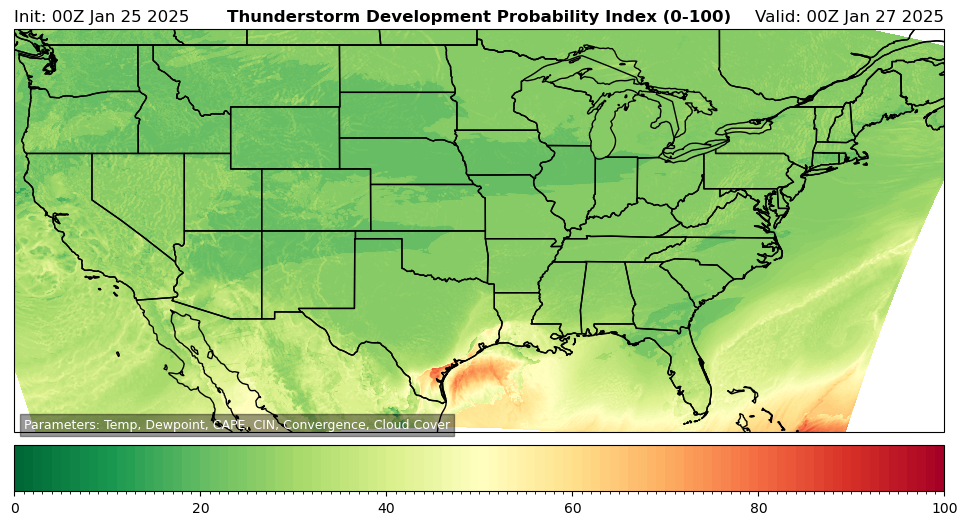

In [259]:
fig, ax = conus_map()

# Define exact boundaries for 0–100
bounds = np.linspace(0, 100, 101)

# Use BoundaryNorm to force exact colorbar edges
norm = mcolors.BoundaryNorm(bounds, ncolors=256)

# Plot with fixed boundaries
c = ax.contourf(
    fcst4['longitude'], 
    fcst4['latitude'], 
    index4,
    cmap='RdYlGn_r',
    levels=bounds,      # <-- exact levels
    norm=norm,          # <-- prevents auto-expansion
    shading='auto'
)

# Add colorbar with ticks exactly at the ends
cb = plt.colorbar(
    c,
    ax=ax,
    orientation='horizontal',
    pad=0.02,
    ticks=[0, 20, 40, 60, 80, 100]   # 0 at left edge, 100 at right edge
)

# Titles
plt.title("Thunderstorm Development Probability Index (0-100)", loc='center', fontweight='bold')
plt.title(f"Init: {init_str}", loc='left')
plt.title(f"Valid: {valid_str}", loc='right')

# Attribution text
plt.text(
    0.01, 0.01,
    "Parameters: Temp, Dewpoint, CAPE, CIN, Convergence, Cloud Cover",
    transform=ax.transAxes,
    fontsize=9,
    color='white',
    bbox=dict(facecolor='black', alpha=0.4, pad=3)
)

plt.show() # Plot of Low-End Thunderstorm Index


# 5. Automated Plot Generation

In [260]:
# Ensure output directory exists
outdir = "threat_plots_Incident_Day"
os.makedirs(outdir, exist_ok=True)

# CONUS Map Function
def conus_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return fig, ax

# Threat index function
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))
    cape_index = 100 * (1 - np.exp(-cape / 1000))
    cin_index = 100 * np.exp(-np.abs(cin) / 100)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

    index1 = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)
    return index1

# Loop over all times in the dataset
for i in range(len(ds1.valid_time)):

    fcst1 = ds1.isel(valid_time=i)

    # Convert times
    init_time = pd.to_datetime(ds1.time.values)
    valid_time = pd.to_datetime(fcst1.valid_time.values)
    init_str = init_time.strftime('%HZ %b %d %Y')
    valid_str = valid_time.strftime('%HZ %b %d %Y')

    # Compute fields
    temp_f = (fcst1['t2m'] - 273.15) * 9/5 + 32
    dewpt_f = (fcst1['d2m'] - 273.15) * 9/5 + 32
    cape = fcst1['cape']
    cin = fcst1['cin']
    cloud = fcst1['tcc'] * 100

    dx, dy = lat_lon_grid_deltas(fcst1['longitude'].values, fcst1['latitude'].values)
    convergence = -mpcalc.divergence(fcst1['u10'], fcst1['v10'], dx=dx, dy=dy)

    # Compute threat index
    index1 = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)

    # Plotted conus map
    fig, ax = conus_map()

    bounds = np.linspace(0, 100, 101)
    norm = mcolors.BoundaryNorm(bounds, ncolors=256)

    c = ax.contourf(
        fcst1['longitude'],
        fcst1['latitude'],
        index1,
        cmap='RdYlGn_r',
        levels=bounds,
        norm=norm,
        shading='auto'
    )

    cb = plt.colorbar(
        c,
        ax=ax,
        orientation='horizontal',
        pad=0.02,
        ticks=[0, 20, 40, 60, 80, 100]
    )

    plt.title("Thunderstorm Development Probability Index (0–100)", loc='center', fontweight='bold')
    plt.title(f"Init: {init_str}", loc='left')
    plt.title(f"Valid: {valid_str}", loc='right')

    plt.text(
        0.01, 0.01,
        "Parameters: Temp, Dewpoint, CAPE, CIN, Convergence, Cloud Cover",
        transform=ax.transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='black', alpha=0.4, pad=3)
    )

    # Save files as pngs and save them in a folder of all 48 hours for incident day
    fname = f"threat_{i:03d}.png"
    plt.savefig(os.path.join(outdir, fname), dpi=150, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved {fname}")


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_000.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_001.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


...

Saved threat_046.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_047.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_048.png


In [261]:
# Ensure output directory exists
outdir = "threat_plots_null_day"
os.makedirs(outdir, exist_ok=True)

# Conus Map Function
def conus_map():
    fig = plt.figure(figsize=(12, 8))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-125, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS)
    ax.add_feature(cfeature.STATES)
    return fig, ax

# Threat index function
def threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud):
    temp = np.clip(100 * np.exp(-((temp_f - 75)**2) / 200), 0, 100)
    dew_point = 100 / (1 + np.exp(-0.2 * (dewpt_f - 60)))
    cape_index = 100 * (1 - np.exp(-cape / 1000))
    cin_index = 100 * np.exp(-np.abs(cin) / 100)
    cloud_cover = 100 / (1 + np.exp(-0.1 * (cloud - 50)))
    convergent_winds = np.clip(convergence * 1e5, 0, 100)

    index2 = (0.15 * temp + 0.25 * dew_point + 0.05 * convergent_winds +
             0.30 * cape_index + 0.20 * cin_index + 0.05 * cloud_cover)
    return index2

# Loop over all times in the dataset
for i in range(len(ds2.valid_time)):

    fcst2 = ds2.isel(valid_time=i)

    # Convert times
    init_time = pd.to_datetime(ds2.time.values)
    valid_time = pd.to_datetime(fcst2.valid_time.values)
    init_str = init_time.strftime('%HZ %b %d %Y')
    valid_str = valid_time.strftime('%HZ %b %d %Y')

    # Compute fields
    temp_f = (fcst2['t2m'] - 273.15) * 9/5 + 32
    dewpt_f = (fcst2['d2m'] - 273.15) * 9/5 + 32
    cape = fcst2['cape']
    cin = fcst2['cin']
    cloud = fcst2['tcc'] * 100

    dx, dy = lat_lon_grid_deltas(fcst2['longitude'].values, fcst2['latitude'].values)
    convergence = -mpcalc.divergence(fcst2['u10'], fcst2['v10'], dx=dx, dy=dy)

    # Compute threat index
    index2 = threat_index(temp_f, dewpt_f, convergence, cape, cin, cloud)

    # Plotted conus map
    fig, ax = conus_map()

    bounds = np.linspace(0, 100, 101)
    norm = mcolors.BoundaryNorm(bounds, ncolors=256)

    c = ax.contourf(
        fcst2['longitude'],
        fcst2['latitude'],
        index2,
        cmap='RdYlGn_r',
        levels=bounds,
        norm=norm,
        shading='auto'
    )

    cb = plt.colorbar(
        c,
        ax=ax,
        orientation='horizontal',
        pad=0.02,
        ticks=[0, 20, 40, 60, 80, 100]
    )

    plt.title("Thunderstorm Development Probability Index (0–100)", loc='center', fontweight='bold')
    plt.title(f"Init: {init_str}", loc='left')
    plt.title(f"Valid: {valid_str}", loc='right')

    plt.text(
        0.01, 0.01,
        "Parameters: Temp, Dewpoint, CAPE, CIN, Convergence, Cloud Cover",
        transform=ax.transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='black', alpha=0.4, pad=3)
    )

    # Save files as pngs and save them in a folder of all 48 hours for incident day
    fname = f"threat_{i:03d}.png"
    plt.savefig(os.path.join(outdir, fname), dpi=150, bbox_inches='tight')
    plt.close(fig)

    print(f"Saved {fname}")


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_000.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_001.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


...

Saved threat_046.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_047.png


/usr/local/anaconda3/envs/custom_envs/meteo473_sp26/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1631: UserWarning: The following kwargs were not used by contour: 'shading'
  result = super().contourf(*args, **kwargs)


Saved threat_048.png


# 6. Convert to Python Script
Our group converted the Milestone 2 notebook into a Python script (threat_index.py) so everything runs automatically from the terminal. The script imports the needed packages, loads the model data, calculates the threat index, and loops through each forecast time to save a .png plot. It also makes sure the output folder exists so the script runs without errors.

# 7. Bouns
As an extra step out group implimented a cron job that would allow the script to run automatically at set times (6 to 12 hours). This could be used to download newest and latest model data, recalculate the threat index, and update the plots. This is fully implemented and should make the workflow more like an operational system.